In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError

In [7]:

data_path = Path.home() / 'projects/anomaly-detection/data/mvtec/'
list(data_path.iterdir())

[PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/capsule'),
 PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/toothbrush'),
 PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/cable'),
 PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/wood'),
 PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/screw'),
 PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/grid'),
 PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/bottle'),
 PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/transistor'),
 PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/license.txt'),
 PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/metal_nut'),
 PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/tile'),
 PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/leather'),
 PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/carpet'),
 PosixPath('/home/ali/projects/anomaly-detection/data/mvtec/pill'),
 PosixPath('

In [2]:
def get_image_metadata(path: str | Path) -> tuple[int | None, int | None, str | None]:
    """Return image width, height, and Pillow mode without loading pixel data.
    Uses PIL to efficiently obtain the image metadata by reading the image header only, without loading the whole image.
    
    Parameters
    ----------
    path : str or Path
        Path to the image file.
    
    Returns
    -------    
    tuple[int | None, int | None, str | None]
        Width, height, and Pillow image mode. Common modes include:  
        ``L``: 8-bit grayscale (0-255)  
        ``RGB``: 3-channels  
        ``RGBA``: RGB + alpha transparency, 4 channels  
        ``1``: binary black/white  
        ``P``: palette-based image  
        ``CMYK``: print-style cyan/magenta/yellow/black
    """
    try:
        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode
        return width, height, mode
    except (UnidentifiedImageError, OSError) as e:
        print(f"Could not read image metadata for {path}:\n{e}")
        return None, None, None

In [4]:
def build_mvtec_manifest(root: str | Path) -> pd.DataFrame:
    root = Path(root)
    
    image_extensions = {".png", ".jpg", ".jpeg", ".bmp"}
    rows = []
    unhandled_files = []

    for product_dir in root.iterdir():
        if not product_dir.is_dir():
            continue

        product = product_dir.name

        # train and test images
        for split in ["train", "test"]:
            split_dir = product_dir / split
            if not split_dir.exists():
                continue

            for defect_dir in split_dir.iterdir():
                if not defect_dir.is_dir():
                    continue

                defect_type = defect_dir.name

                for image_path in defect_dir.iterdir():
                    if image_path.suffix.lower() not in image_extensions:
                        unhandled_files.append(image_path)
                        continue
                    
                    width, height, mode = get_image_metadata(image_path)
                    
                    image_id = image_path.stem
                    file_size_bytes = image_path.stat().st_size
                    mask_path = product_dir / "ground_truth" / defect_type / f"{image_id}_mask.png"

                    rows.append({
                        "path": image_path,
                        "filename": image_path.name,
                        "image_id": image_id,
                        "product": product,
                        "split": split,
                        "defect_type": defect_type,
                        "kind": "image",
                        "is_good": defect_type == "good",
                        "is_defect": split == "test" and defect_type != "good",
                        "has_mask": mask_path.exists(),
                        "mask_path": str(mask_path) if mask_path.exists() else None,
                        "width": width,
                        "height": height,
                        "mode": mode,
                        "aspect_ratio": width / height if width and height else None,
                        "megapixels": width * height / 1_000_000 if width and height else None,
                        "file_size_bytes": file_size_bytes,
                        "file_size_kb": round(file_size_bytes / 1024, 2),
                        "suffix": image_path.suffix.lower(),
                    })

        # ground truth masks
        gt_dir = product_dir / "ground_truth"
        if gt_dir.exists():
            for defect_dir in gt_dir.iterdir():
                if not defect_dir.is_dir():
                    continue

                defect_type = defect_dir.name

                for mask_path in defect_dir.iterdir():
                    if mask_path.suffix.lower() not in image_extensions:
                        unhandled_files.append(mask_path)
                        continue

                    width, height, mode = get_image_metadata(mask_path)

                    image_id = mask_path.stem.removesuffix("_mask")
                    file_size_bytes = mask_path.stat().st_size

                    rows.append({
                        "path": mask_path,
                        "filename": mask_path.name,
                        "image_id": image_id,
                        "product": product,
                        "split": "ground_truth",
                        "defect_type": defect_type,
                        "kind": "mask",
                        "is_good": False,
                        "is_defect": False,
                        "has_mask": False,
                        "mask_path": None,
                        "width": width,
                        "height": height,
                        "mode": mode,
                        "aspect_ratio": width / height if width and height else None,
                        "megapixels": width * height / 1_000_000 if width and height else None,
                        "file_size_bytes": file_size_bytes,
                        "file_size_kb": round(file_size_bytes / 1024, 2),
                        "suffix": mask_path.suffix.lower(),
                    })

    df = pd.DataFrame(rows)

    if not df.empty:
        df["path"] = df["path"].astype(str)
        
    if unhandled_files:
        print(f'There were {len(unhandled_files)} files not taken into consideration, e.g.: {unhandled_files[:3]}')

    return df

In [8]:
df = build_mvtec_manifest(data_path)

In [9]:
df.head()

,path,filename,image_id,product,split,defect_type,kind,is_good,is_defect,has_mask,mask_path,width,height,mode,aspect_ratio,megapixels,file_size_bytes,file_size_kb,suffix
0,/home/ali/projects/anomaly-detection/data/mvte...,151.png,151,capsule,train,good,image,True,False,False,NaN,1000,1000,RGB,1.0,1.0,1115933,1089.78,.png
1,/home/ali/projects/anomaly-detection/data/mvte...,209.png,209,capsule,train,good,image,True,False,False,NaN,1000,1000,RGB,1.0,1.0,1162560,1135.31,.png
2,/home/ali/projects/anomaly-detection/data/mvte...,022.png,022,capsule,train,good,image,True,False,False,NaN,1000,1000,RGB,1.0,1.0,1161002,1133.79,.png
3,/home/ali/projects/anomaly-detection/data/mvte...,208.png,208,capsule,train,good,image,True,False,False,NaN,1000,1000,RGB,1.0,1.0,1150679,1123.71,.png
4,/home/ali/projects/anomaly-detection/data/mvte...,013.png,013,capsule,train,good,image,True,False,False,NaN,1000,1000,RGB,1.0,1.0,1146994,1120.11,.png


In [10]:
df.describe()

,width,height,aspect_ratio,megapixels,file_size_bytes,file_size_kb
count,6612.000000,6612.000000,6612.0,6612.000000,6.612000e+03,6612.000000
mean,963.226255,963.226255,1.0,0.938343,7.971717e+05,778.487961
std,102.661029,102.661029,0.0,0.182908,5.706564e+05,557.281630
min,700.000000,700.000000,1.0,0.490000,8.350000e+02,0.820000
25%,900.000000,900.000000,1.0,0.810000,4.066345e+05,397.107500
50%,1024.000000,1024.000000,1.0,1.048576,6.323165e+05,617.500000
75%,1024.000000,1024.000000,1.0,1.048576,1.285047e+06,1254.930000
max,1024.000000,1024.000000,1.0,1.048576,1.986653e+06,1940.090000


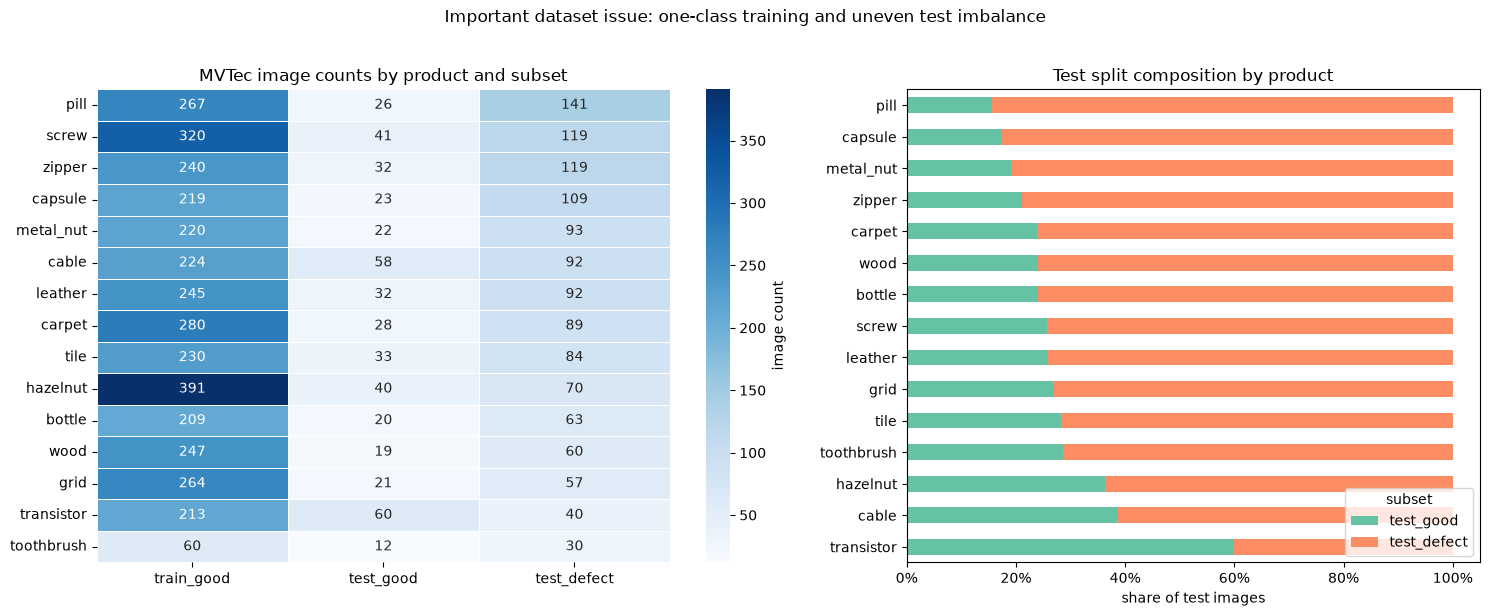

In [11]:
image_df = df[df["kind"].eq("image")].copy()

image_df["subset"] = np.select(
    [
        image_df["split"].eq("train") & image_df["is_good"],
        image_df["split"].eq("test") & image_df["is_good"],
        image_df["split"].eq("test") & image_df["is_defect"],
    ],
    ["train_good", "test_good", "test_defect"],
    default="other",
)

count_table = (
    image_df.groupby(["product", "subset"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["train_good", "test_good", "test_defect"], fill_value=0)
    .sort_values("test_defect", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), width_ratios=[1.25, 1])

sns.heatmap(
    count_table,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "image count"},
    ax=axes[0],
)
axes[0].set_title("MVTec image counts by product and subset")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

test_mix = count_table[["test_good", "test_defect"]]
test_mix_pct = test_mix.div(test_mix.sum(axis=1), axis=0).sort_values("test_defect")
test_mix_pct.plot(kind="barh", stacked=True, ax=axes[1], color=["#66c2a5", "#fc8d62"])
axes[1].set_title("Test split composition by product")
axes[1].set_xlabel("share of test images")
axes[1].set_ylabel("")
axes[1].legend(title="subset", loc="lower right")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

fig.suptitle("Important dataset issue: one-class training and uneven test imbalance", y=1.02)
fig.tight_layout()
